In [1]:
import os, sys, json, hashlib, zipfile, shutil, subprocess
from pathlib import Path
from datetime import datetime, timezone

import requests
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm


ZENODO_DOI   = "10.5281/zenodo.6467268"
SRC_URL      = "https://zenodo.org/records/6467268/files/diagnosis_test_dataset.zip?download=1"
SRC_NAME     = "diagnosis_test_dataset.zip"
EXPECTED_MD5 = "76c20a6c5f566c2f141b6dd274ea4d74"

LONG_EDGE    = 1024
JPEG_QUALITY = 88

N_SAMPLES    = 65
N_PER_SAMPLE = 117
N_TOTAL      = N_SAMPLES * N_PER_SAMPLE   # 7605

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# scratch dir (not persisted) — falls back to /tmp if /kaggle/temp is unavailable
def _pick_scratch():
    for cand in ("/kaggle/temp", "/tmp"):
        p = Path(cand)
        try:
            p.mkdir(parents=True, exist_ok=True)
            (p / ".wtest").write_text("x"); (p / ".wtest").unlink()
            return p
        except Exception:
            continue
    raise RuntimeError("no writable scratch directory")

SCRATCH = _pick_scratch()
ZIP_PATH = SCRATCH / SRC_NAME
RAW_DIR  = SCRATCH / "raw"
OUT_DIR  = Path("/kaggle/working/bilharz-diagnosis-65")

print("scratch:", SCRATCH)
print("output :", OUT_DIR)
print("free on scratch: %.1f GB" % (shutil.disk_usage(SCRATCH).free / 1e9))
print("free on /kaggle/working: %.1f GB" % (shutil.disk_usage("/kaggle/working").free / 1e9))

scratch: /kaggle/temp
output : /kaggle/working/bilharz-diagnosis-65
free on scratch: 1148.8 GB
free on /kaggle/working: 20.9 GB


In [2]:
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

N_CONN   = 16
RETRIES  = 4
CHUNK    = 4 * 1024 * 1024

supports_range = True
TOTAL = 12519018775          # Content-Length reported by Zenodo on the first run
print(f"total: {TOTAL:,} bytes ({TOTAL/1e9:.2f} GB)")

# --- preallocate ------------------------------------------------------------
with open(ZIP_PATH, "wb") as f:
    f.truncate(TOTAL)

bar  = tqdm(total=TOTAL, unit="B", unit_scale=True, unit_divisor=1024, desc="download")
lock = threading.Lock()

def fetch_range(idx, start, end):
    """Download bytes [start, end] inclusive into ZIP_PATH at offset start."""
    for attempt in range(RETRIES):
        pos = start
        try:
            hdrs = {"Range": f"bytes={pos}-{end}"}
            with requests.get(SRC_URL, headers=hdrs, stream=True,
                              allow_redirects=True, timeout=(30, 300)) as resp:
                if resp.status_code != 206:
                    raise RuntimeError(
                        f"expected 206 Partial Content, got {resp.status_code} "
                        f"(server ignored the Range header)"
                    )
                with open(ZIP_PATH, "r+b") as f:
                    f.seek(pos)
                    for chunk in resp.iter_content(chunk_size=CHUNK):
                        if not chunk:
                            continue
                        f.write(chunk)
                        pos += len(chunk)
                        with lock:
                            bar.update(len(chunk))
            if pos - 1 == end:
                return idx, True, None
            raise RuntimeError(f"short segment: got {pos-start} of {end-start+1}")
        except Exception as e:
            got = pos - start
            with lock:
                bar.update(-got)          # rewind the bar before retrying
            if attempt == RETRIES - 1:
                return idx, False, f"{type(e).__name__}: {e}"
    return idx, False, "exhausted retries"

seg = TOTAL // N_CONN
bounds = []
for i in range(N_CONN):
    s = i * seg
    e = TOTAL - 1 if i == N_CONN - 1 else (s + seg - 1)
    bounds.append((i, s, e))

failures = []
with ThreadPoolExecutor(max_workers=N_CONN) as ex:
    futs = [ex.submit(fetch_range, i, s, e) for i, s, e in bounds]
    for fut in as_completed(futs):
        idx, ok, err = fut.result()
        if not ok:
            failures.append((idx, err))
bar.close()
assert not failures, f"segments failed: {failures}"

assert ZIP_PATH.stat().st_size == TOTAL, \
    f"size mismatch: {ZIP_PATH.stat().st_size} vs {TOTAL}"

# verify integrity (second pass over the file) 
md5 = hashlib.md5()
with open(ZIP_PATH, "rb") as f, tqdm(total=TOTAL, unit="B", unit_scale=True,
                                     unit_divisor=1024, desc="md5") as b3:
    while True:
        blk = f.read(16 * 1024 * 1024)
        if not blk:
            break
        md5.update(blk); b3.update(len(blk))

actual_md5 = md5.hexdigest()
print(f"\ndownloaded {ZIP_PATH.stat().st_size/1e9:.2f} GB")
print("md5 actual  :", actual_md5)
print("md5 expected:", EXPECTED_MD5)

assert actual_md5 == EXPECTED_MD5, (
    f"MD5 MISMATCH — corrupt or truncated. got {actual_md5}, expected {EXPECTED_MD5}."
)
print("\n✓ integrity verified")

total: 12,519,018,775 bytes (12.52 GB)


download:   0%|          | 0.00/11.7G [00:00<?, ?B/s]

md5:   0%|          | 0.00/11.7G [00:00<?, ?B/s]


downloaded 12.52 GB
md5 actual  : 76c20a6c5f566c2f141b6dd274ea4d74
md5 expected: 76c20a6c5f566c2f141b6dd274ea4d74

✓ integrity verified


In [3]:
RAW_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH) as zf:
    members = zf.infolist()
    print(f"{len(members)} entries in archive")
    for m in tqdm(members, desc="extract"):
        zf.extract(m, RAW_DIR)

ZIP_PATH.unlink()
print("zip deleted")
print("free on scratch: %.1f GB" % (shutil.disk_usage(SCRATCH).free / 1e9))

# locate the directory that actually holds DT01..DT65
def find_root(base: Path) -> Path:
    for d in [base, *[p for p in base.rglob("*") if p.is_dir()]]:
        names = {p.name for p in d.iterdir() if p.is_dir()}
        if {"DT01", "DT65"} <= names:
            return d
    raise RuntimeError("could not locate the DT01..DT65 directory")

DATA_ROOT = find_root(RAW_DIR)
print("data root:", DATA_ROOT)

7672 entries in archive


extract:   0%|          | 0/7672 [00:00<?, ?it/s]

zip deleted
free on scratch: 1136.1 GB
data root: /kaggle/temp/raw/diagnosis_test_dataset


In [4]:
sample_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()], key=lambda p: p.name)
sample_ids  = [p.name for p in sample_dirs]

expected_ids = [f"DT{i:02d}" for i in range(1, N_SAMPLES + 1)]
assert sample_ids == expected_ids, (
    f"sample directories do not match DT01..DT{N_SAMPLES}. got {len(sample_ids)}: {sample_ids[:5]}..."
)

counts, total_imgs = {}, 0
for d in sample_dirs:
    imgs = [p for p in d.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
    counts[d.name] = len(imgs)
    total_imgs += len(imgs)

bad = {k: v for k, v in counts.items() if v != N_PER_SAMPLE}
assert not bad, f"samples with wrong image count (expected {N_PER_SAMPLE}): {bad}"
assert total_imgs == N_TOTAL, f"expected {N_TOTAL} images, found {total_imgs}"

csv_candidates = list(DATA_ROOT.rglob("microscopist_result.csv"))
assert csv_candidates, "microscopist_result.csv not found"
CSV_PATH = csv_candidates[0]

labels = pd.read_csv(CSV_PATH)
labels.columns = [c.strip() for c in labels.columns]
for col in ("sample_id", "egg_count", "diagnosis"):
    assert col in labels.columns, f"missing column '{col}' — found {list(labels.columns)}"

def _to_bin(v):
    s = str(v).strip().lower()
    if s.startswith("p") or s in {"1", "1.0", "true", "yes"}:  return 1
    if s.startswith("n") or s in {"0", "0.0", "false", "no"}:  return 0
    raise ValueError(f"unrecognised diagnosis value: {v!r}")

labels["_bin"] = labels["diagnosis"].map(_to_bin)
n_pos, n_neg = int(labels["_bin"].sum()), int((labels["_bin"] == 0).sum())
print(f"labels: {len(labels)} rows — {n_pos} positive, {n_neg} negative")
assert len(labels) == N_SAMPLES, f"expected {N_SAMPLES} label rows, got {len(labels)}"
assert (n_pos, n_neg) == (32, 33), f"expected 32 positive / 33 negative, got {n_pos}/{n_neg}"
assert set(labels["sample_id"].astype(str)) == set(expected_ids), "sample_id values do not match folders"

print("\nper-sample image counts")
print(pd.Series(counts, name="n_images").to_frame().T.to_string())
print(f"\negg_count range: {labels['egg_count'].min()} – {labels['egg_count'].max()}")
print(f"positives with <=5 eggs: {int(((labels['_bin']==1) & (labels['egg_count']<=5)).sum())}")
print("\n✓ structure verified")

labels: 65 rows — 32 positive, 33 negative

per-sample image counts
          DT01  DT02  DT03  DT04  DT05  DT06  DT07  DT08  DT09  DT10  DT11  DT12  DT13  DT14  DT15  DT16  DT17  DT18  DT19  DT20  DT21  DT22  DT23  DT24  DT25  DT26  DT27  DT28  DT29  DT30  DT31  DT32  DT33  DT34  DT35  DT36  DT37  DT38  DT39  DT40  DT41  DT42  DT43  DT44  DT45  DT46  DT47  DT48  DT49  DT50  DT51  DT52  DT53  DT54  DT55  DT56  DT57  DT58  DT59  DT60  DT61  DT62  DT63  DT64  DT65
n_images   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117   117

egg_count range: 0 – 516
positives with <=5 eggs: 9

✓ structure verified


In [5]:
from concurrent.futures import ProcessPoolExecutor

RESAMPLE = getattr(getattr(Image, "Resampling", Image), "LANCZOS")

def process_one(args):
    src_str, sample_id, out_root_str = args
    src = Path(src_str)
    dst = Path(out_root_str) / sample_id / (src.stem + ".jpg")
    dst.parent.mkdir(parents=True, exist_ok=True)

    with Image.open(src) as im:
        ow, oh = im.size
        scale = LONG_EDGE / max(ow, oh)
        if scale < 1.0:
            nw, nh = max(1, round(ow * scale)), max(1, round(oh * scale))
            im = im.resize((nw, nh), RESAMPLE)
        else:
            nw, nh = ow, oh
        if im.mode != "RGB":
            im = im.convert("RGB")
        im.save(dst, "JPEG", quality=JPEG_QUALITY, optimize=True)

    return {
        "sample_id": sample_id,
        "filename": dst.name,
        "relpath": f"{sample_id}/{dst.name}",
        "orig_width": ow, "orig_height": oh,
        "new_width": nw, "new_height": nh,
        "orig_bytes": src.stat().st_size,
        "new_bytes": dst.stat().st_size,
    }

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

jobs = []
for d in sample_dirs:
    for p in sorted(d.iterdir()):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            jobs.append((str(p), d.name, str(OUT_DIR)))

workers = max(1, (os.cpu_count() or 2))
print(f"{len(jobs)} images, {workers} workers")

rows = []
with ProcessPoolExecutor(max_workers=workers) as ex:
    for rec in tqdm(ex.map(process_one, jobs, chunksize=16), total=len(jobs), desc="resize"):
        rows.append(rec)

print(f"\n✓ {len(rows)} images written")

7605 images, 4 workers


resize:   0%|          | 0/7605 [00:00<?, ?it/s]


✓ 7605 images written


In [6]:
manifest = pd.DataFrame(rows).sort_values(["sample_id", "filename"]).reset_index(drop=True)
manifest.to_csv(OUT_DIR / "manifest.csv", index=False)

labels.drop(columns=["_bin"]).to_csv(OUT_DIR / "microscopist_result.csv", index=False)

provenance = {
    "dataset_name": "bilharz-diagnosis-65",
    "description": (
        "Derived mirror of the Schistosoma haematobium diagnosis test dataset: "
        "65 urine samples, 117 field-of-view images each, resized for patient-level "
        "aggregation experiments. Not a substitute for the original archive."
    ),
    "source": {
        "doi": ZENODO_DOI,
        "record_url": "https://zenodo.org/records/6467268",
        "file": SRC_NAME,
        "download_url": SRC_URL,
        "md5_verified": EXPECTED_MD5,
        "license": "CC-BY-4.0",
    },
    "transform": {
        "operation": "resize longest edge, preserve aspect ratio",
        "long_edge_px": LONG_EDGE,
        "resample": "Lanczos",
        "format": "JPEG",
        "jpeg_quality": JPEG_QUALITY,
        "filenames": "original stems preserved, extension normalised to .jpg",
        "structure": "<sample_id>/<original_stem>.jpg",
    },
    "contents": {
        "n_samples": int(manifest["sample_id"].nunique()),
        "n_images": int(len(manifest)),
        "images_per_sample": N_PER_SAMPLE,
        "n_positive_samples": n_pos,
        "n_negative_samples": n_neg,
    },
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
(OUT_DIR / "provenance.json").write_text(json.dumps(provenance, indent=2))

print(json.dumps(provenance, indent=2))

{
  "dataset_name": "bilharz-diagnosis-65",
  "description": "Derived mirror of the Schistosoma haematobium diagnosis test dataset: 65 urine samples, 117 field-of-view images each, resized for patient-level aggregation experiments. Not a substitute for the original archive.",
  "source": {
    "doi": "10.5281/zenodo.6467268",
    "record_url": "https://zenodo.org/records/6467268",
    "file": "diagnosis_test_dataset.zip",
    "download_url": "https://zenodo.org/records/6467268/files/diagnosis_test_dataset.zip?download=1",
    "md5_verified": "76c20a6c5f566c2f141b6dd274ea4d74",
    "license": "CC-BY-4.0"
  },
  "transform": {
    "operation": "resize longest edge, preserve aspect ratio",
    "long_edge_px": 1024,
    "resample": "Lanczos",
    "format": "JPEG",
    "jpeg_quality": 88,
    "filenames": "original stems preserved, extension normalised to .jpg",
    "structure": "<sample_id>/<original_stem>.jpg"
  },
  "contents": {
    "n_samples": 65,
    "n_images": 7605,
    "images_per

In [7]:
out_files = [p for p in OUT_DIR.rglob("*") if p.is_file()]
out_imgs  = [p for p in out_files if p.suffix.lower() == ".jpg"]
out_bytes = sum(p.stat().st_size for p in out_files)

assert len(out_imgs) == N_TOTAL, f"expected {N_TOTAL} output images, found {len(out_imgs)}"
assert manifest["sample_id"].nunique() == N_SAMPLES
assert (manifest.groupby("sample_id").size() == N_PER_SAMPLE).all()

orig_gb = manifest["orig_bytes"].sum() / 1e9
new_gb  = manifest["new_bytes"].sum() / 1e9

print("=" * 58)
print("bilharz-diagnosis-65 — build complete")
print("=" * 58)
print(f"samples              : {manifest['sample_id'].nunique()}")
print(f"images               : {len(out_imgs)}  (117 x 65 = {N_TOTAL})")
print(f"labels               : {n_pos} positive / {n_neg} negative")
print(f"output size          : {out_bytes/1e9:.2f} GB")
print(f"source size          : {orig_gb:.2f} GB  ->  {new_gb:.2f} GB  ({new_gb/orig_gb*100:.1f}%)")
print(f"per-image bytes      : mean {manifest['new_bytes'].mean()/1e3:.0f} KB  "
      f"min {manifest['new_bytes'].min()/1e3:.0f} KB  "
      f"max {manifest['new_bytes'].max()/1e3:.0f} KB")
print(f"original resolution  : {manifest['orig_width'].mode()[0]} x {manifest['orig_height'].mode()[0]}")
print(f"output resolution    : {manifest['new_width'].mode()[0]} x {manifest['new_height'].mode()[0]}")
print("=" * 58)

bilharz-diagnosis-65 — build complete
samples              : 65
images               : 7605  (117 x 65 = 7605)
labels               : 32 positive / 33 negative
output size          : 0.89 GB
source size          : 12.73 GB  ->  0.89 GB  (7.0%)
per-image bytes      : mean 117 KB  min 22 KB  max 237 KB
original resolution  : 2028 x 1520
output resolution    : 1024 x 767


DT29: 516 eggs


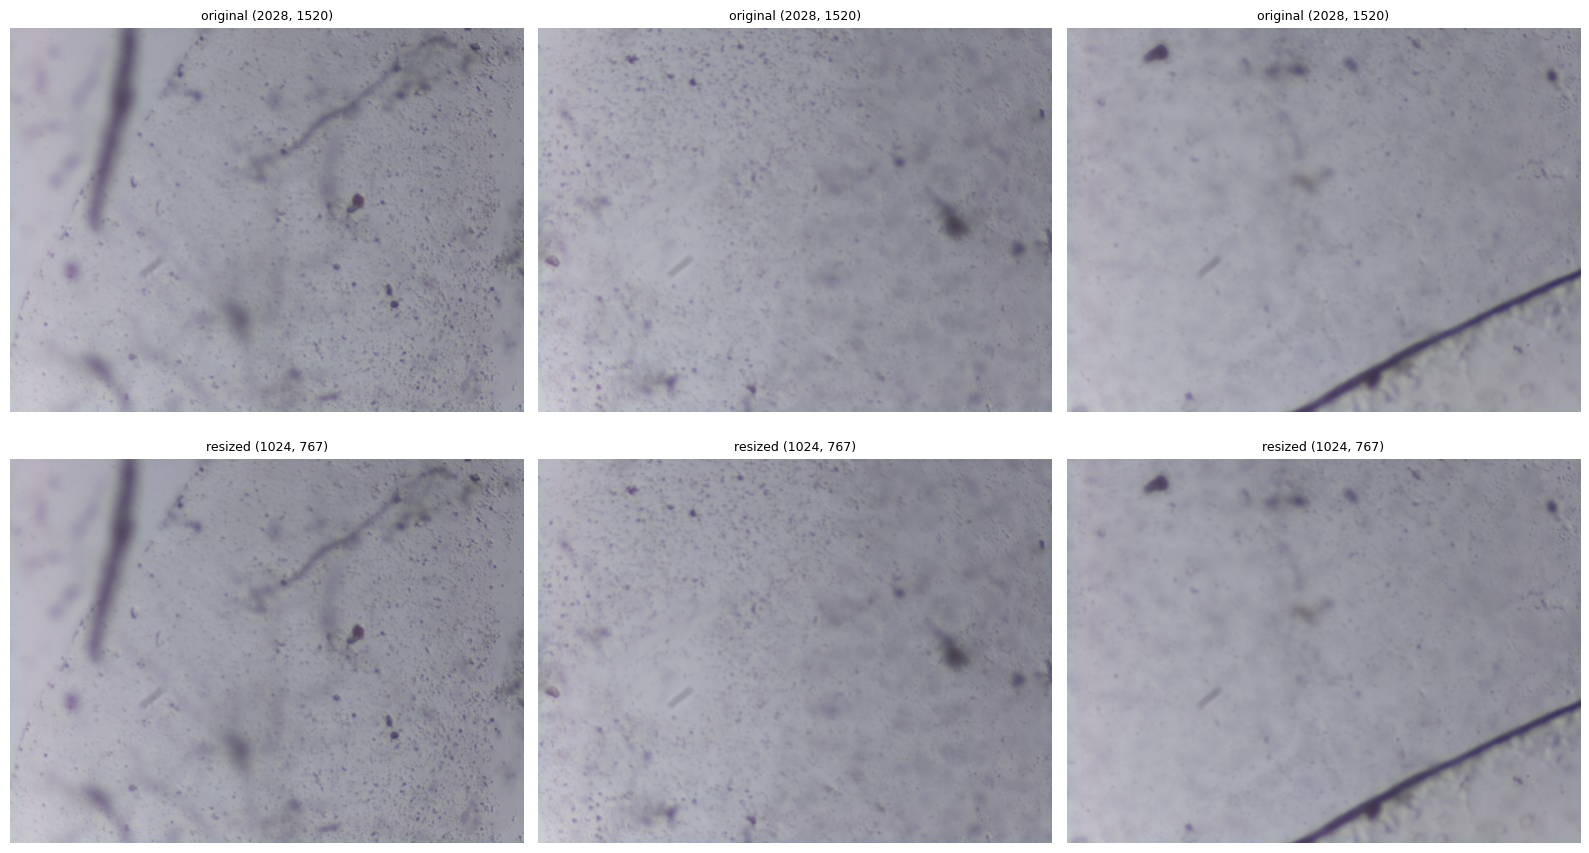

In [8]:
import matplotlib.pyplot as plt

# heaviest positive sample — eggs in most FoVs
top = labels.sort_values("egg_count", ascending=False).iloc[0]
sid = str(top["sample_id"])
print(f"{sid}: {int(top['egg_count'])} eggs")

raw_imgs = sorted([p for p in (DATA_ROOT / sid).iterdir()
                   if p.suffix.lower() in IMG_EXTS])[:3]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for j, rp in enumerate(raw_imgs):
    with Image.open(rp) as im:
        axes[0, j].imshow(im); axes[0, j].set_title(f"original {im.size}", fontsize=9)
    op = OUT_DIR / sid / (rp.stem + ".jpg")
    with Image.open(op) as im:
        axes[1, j].imshow(im); axes[1, j].set_title(f"resized {im.size}", fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout(); plt.show()

crop at (96, 96) in original coords
original crop (384, 384)   resized crop (194, 194)


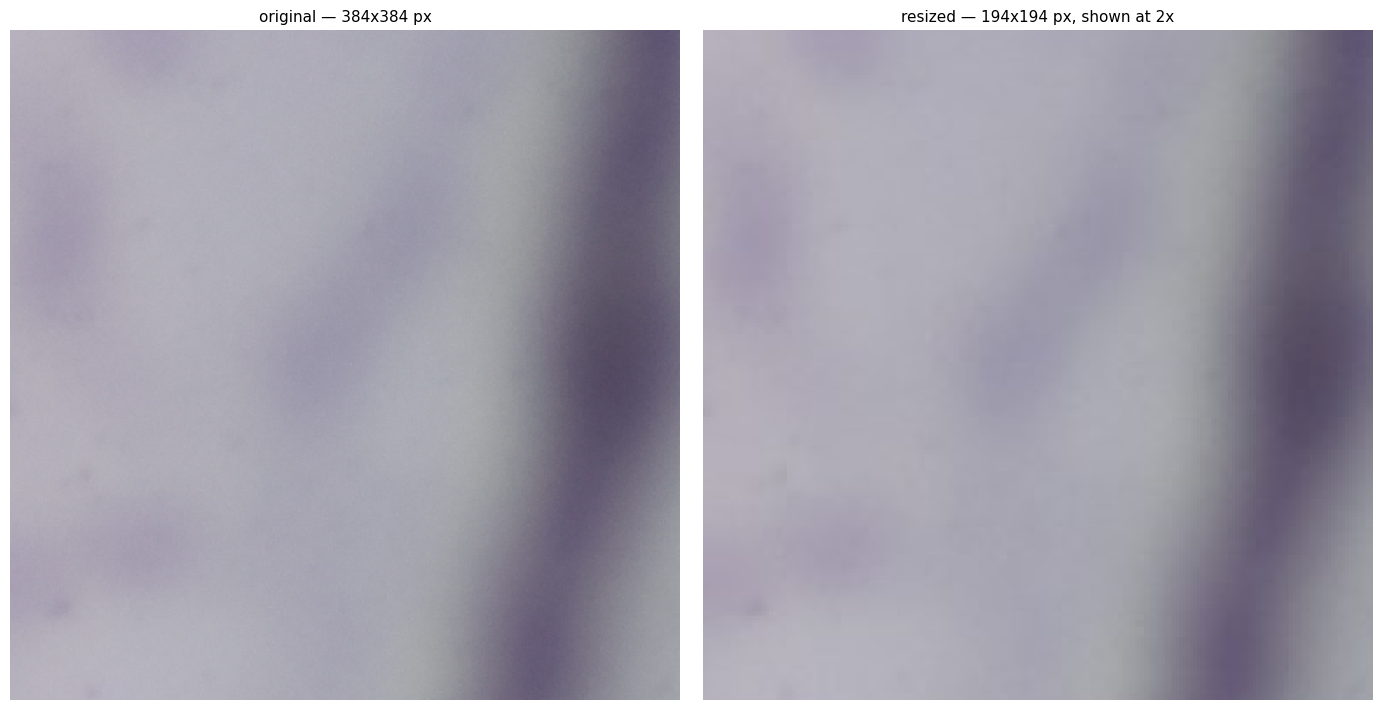

In [9]:
import numpy as np

sid = "DT29"
rp  = sorted([p for p in (DATA_ROOT / sid).iterdir() if p.suffix.lower() in IMG_EXTS])[0]
op  = OUT_DIR / sid / (rp.stem + ".jpg")

orig = Image.open(rp).convert("RGB")
small = Image.open(op).convert("RGB")
sx = small.width / orig.width          # ~0.505

# find the 384x384 window with the most local structure
g = np.asarray(orig.convert("L"), dtype=np.float32)
W, step, best = 384, 96, (-1, 0, 0)
for y in range(0, g.shape[0] - W, step):
    for x in range(0, g.shape[1] - W, step):
        s = g[y:y+W, x:x+W].std()
        if s > best[0]:
            best = (s, x, y)
_, bx, by = best
print(f"crop at ({bx}, {by}) in original coords")

oc = orig.crop((bx, by, bx + W, by + W))
sc = small.crop((round(bx*sx), round(by*sx), round((bx+W)*sx), round((by+W)*sx)))
print(f"original crop {oc.size}   resized crop {sc.size}")

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(oc, interpolation="nearest")
ax[0].set_title(f"original — {oc.size[0]}x{oc.size[1]} px", fontsize=11)
ax[1].imshow(sc.resize(oc.size, Image.NEAREST), interpolation="nearest")
ax[1].set_title(f"resized — {sc.size[0]}x{sc.size[1]} px, shown at 2x", fontsize=11)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

In [10]:
def process_one_v2(args):
    src_str, sample_id, out_root_str, long_edge, quality = args
    src = Path(src_str)
    dst = Path(out_root_str) / sample_id / (src.stem + ".jpg")
    dst.parent.mkdir(parents=True, exist_ok=True)
    with Image.open(src) as im:
        ow, oh = im.size
        scale = long_edge / max(ow, oh)
        if scale < 1.0:
            nw, nh = max(1, round(ow*scale)), max(1, round(oh*scale))
            im = im.resize((nw, nh), RESAMPLE)
        else:
            nw, nh = ow, oh
        if im.mode != "RGB":
            im = im.convert("RGB")
        im.save(dst, "JPEG", quality=quality, optimize=True)
    return {"sample_id": sample_id, "filename": dst.name,
            "relpath": f"{sample_id}/{dst.name}",
            "orig_width": ow, "orig_height": oh,
            "new_width": nw, "new_height": nh,
            "orig_bytes": src.stat().st_size, "new_bytes": dst.stat().st_size}

LONG_EDGE_HI = 1520
OUT_DIR_HI = Path("/kaggle/working/bilharz-diagnosis-65-1520")
if OUT_DIR_HI.exists():
    shutil.rmtree(OUT_DIR_HI)
OUT_DIR_HI.mkdir(parents=True, exist_ok=True)

jobs_hi = [(str(p), d.name, str(OUT_DIR_HI), LONG_EDGE_HI, JPEG_QUALITY)
           for d in sample_dirs
           for p in sorted(d.iterdir())
           if p.is_file() and p.suffix.lower() in IMG_EXTS]

rows_hi = []
with ProcessPoolExecutor(max_workers=workers) as ex:
    for rec in tqdm(ex.map(process_one_v2, jobs_hi, chunksize=16),
                    total=len(jobs_hi), desc="resize 1520"):
        rows_hi.append(rec)

man_hi = pd.DataFrame(rows_hi).sort_values(["sample_id", "filename"]).reset_index(drop=True)
man_hi.to_csv(OUT_DIR_HI / "manifest.csv", index=False)
labels.drop(columns=["_bin"]).to_csv(OUT_DIR_HI / "microscopist_result.csv", index=False)

prov_hi = json.loads(json.dumps(provenance))
prov_hi["dataset_name"] = "bilharz-diagnosis-65-1520"
prov_hi["transform"]["long_edge_px"] = LONG_EDGE_HI
prov_hi["generated_utc"] = datetime.now(timezone.utc).isoformat(timespec="seconds")
(OUT_DIR_HI / "provenance.json").write_text(json.dumps(prov_hi, indent=2))

assert len(rows_hi) == N_TOTAL
print(f"\n✓ {len(rows_hi)} images at {LONG_EDGE_HI} px — "
      f"{man_hi['new_bytes'].sum()/1e9:.2f} GB")

resize 1520:   0%|          | 0/7605 [00:00<?, ?it/s]


✓ 7605 images at 1520 px — 1.61 GB


In [11]:
print(sum(1 for _ in Path("/kaggle/working").rglob("*.jpg")), "images still present")

15210 images still present
